In [18]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [19]:
# Load the Dataset
df = pd.read_csv('/content/E-commerce Customer Behavior.csv')

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully!
Shape: (350, 11)


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [20]:
# Data Info
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Column Names: ['Customer ID', 'Gender', 'Age', 'City', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level']

Data Types:
Customer ID                   int64
Gender                       object
Age                           int64
City                         object
Membership Type              object
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied               bool
Days Since Last Purchase      int64
Satisfaction Level           object
dtype: object

Missing Values:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


In [21]:
# Data Cleaning
df['Satisfaction Level'] = df['Satisfaction Level'].fillna('Neutral')

print("Data Cleaned Successfully!")
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Data Cleaned Successfully!

Missing Values After Cleaning:
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64


In [22]:
# Create 'Converted' Column
df['Converted'] = df['Satisfaction Level'].apply(lambda x: 1 if x == 'Satisfied' else 0)

print("Converted Column Created Successfully!")
print("\nSample Data:")
print(df[['Satisfaction Level', 'Converted']].head(10))
print("\nConverted Value Counts:")
print(df['Converted'].value_counts())

Converted Column Created Successfully!

Sample Data:
  Satisfaction Level  Converted
0          Satisfied          1
1            Neutral          0
2        Unsatisfied          0
3          Satisfied          1
4        Unsatisfied          0
5            Neutral          0
6          Satisfied          1
7            Neutral          0
8        Unsatisfied          0
9          Satisfied          1

Converted Value Counts:
Converted
0    225
1    125
Name: count, dtype: int64


In [23]:
# Overall Conversion Rate
total = df.shape[0]
converted = df['Converted'].sum()
conversion_rate = (converted / total) * 100

print("=" * 45)
print("   OVERALL E-COMMERCE CONVERSION RATE")
print("=" * 45)
print(f"Total Customers  : {total}")
print(f"Converted        : {converted}")
print(f"Not Converted    : {total - converted}")
print(f"Conversion Rate  : {conversion_rate:.2f}%")
print("=" * 45)

   OVERALL E-COMMERCE CONVERSION RATE
Total Customers  : 350
Converted        : 125
Not Converted    : 225
Conversion Rate  : 35.71%


/tmp/ipykernel_6901/1101198486.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conv_membership.index, y=conv_membership.values, palette='Set2')


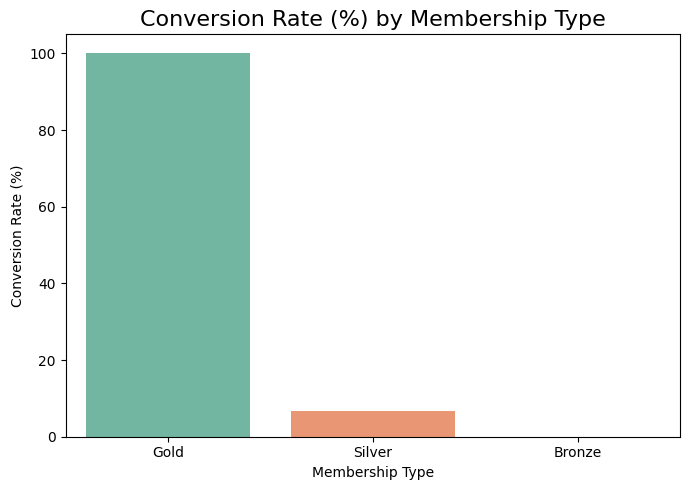

Membership Type
Gold      100.00
Silver      6.84
Bronze      0.00
Name: Converted, dtype: float64


In [24]:
# Conversion Rate by Membership Type
conv_membership = df.groupby('Membership Type')['Converted'].mean() * 100
conv_membership = conv_membership.sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=conv_membership.index, y=conv_membership.values, palette='Set2')
plt.title('Conversion Rate (%) by Membership Type', fontsize=16)
plt.xlabel('Membership Type')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

print(conv_membership.round(2))


/tmp/ipykernel_6901/2374206350.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conv_city.index, y=conv_city.values, palette='viridis')


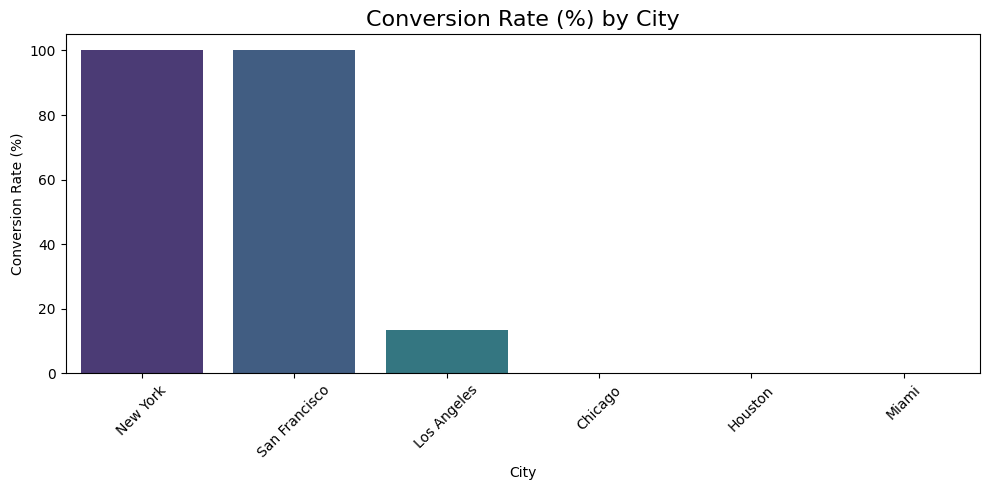

City
New York         100.00
San Francisco    100.00
Los Angeles       13.56
Chicago            0.00
Houston            0.00
Miami              0.00
Name: Converted, dtype: float64


In [25]:
# Conversion Rate by City
conv_city = df.groupby('City')['Converted'].mean() * 100
conv_city = conv_city.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=conv_city.index, y=conv_city.values, palette='viridis')
plt.title('Conversion Rate (%) by City', fontsize=16)
plt.xlabel('City')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(conv_city.round(2))

/tmp/ipykernel_6901/2785583139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conv_gender.index, y=conv_gender.values, palette='pastel')


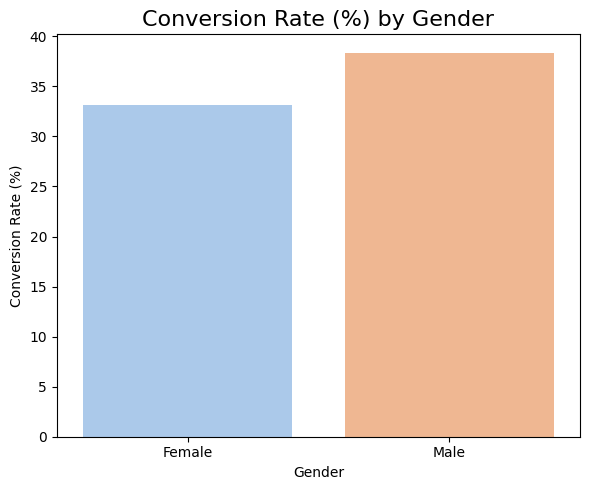

Gender
Female    33.14
Male      38.29
Name: Converted, dtype: float64


In [26]:
# Conversion Rate by Gender
conv_gender = df.groupby('Gender')['Converted'].mean() * 100

plt.figure(figsize=(6, 5))
sns.barplot(x=conv_gender.index, y=conv_gender.values, palette='pastel')
plt.title('Conversion Rate (%) by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

print(conv_gender.round(2))

/tmp/ipykernel_6901/1927326737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conv_discount.index.astype(str), y=conv_discount.values, palette='magma')


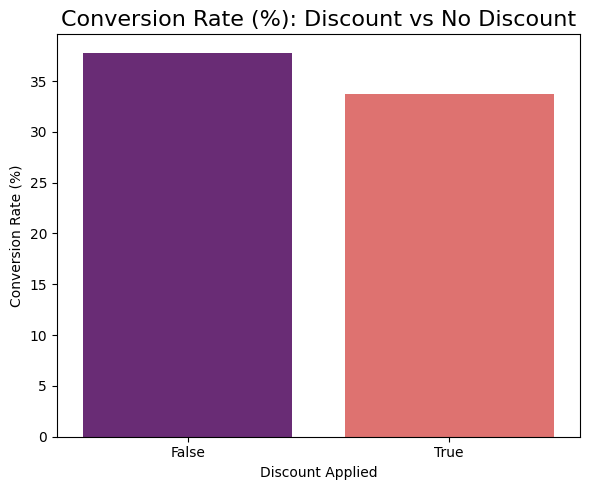

Discount Applied
False    37.71
True     33.71
Name: Converted, dtype: float64


In [27]:
# Conversion Rate by Discount Applied
conv_discount = df.groupby('Discount Applied')['Converted'].mean() * 100

plt.figure(figsize=(6, 5))
sns.barplot(x=conv_discount.index.astype(str), y=conv_discount.values, palette='magma')
plt.title('Conversion Rate (%): Discount vs No Discount', fontsize=16)
plt.xlabel('Discount Applied')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

print(conv_discount.round(2))

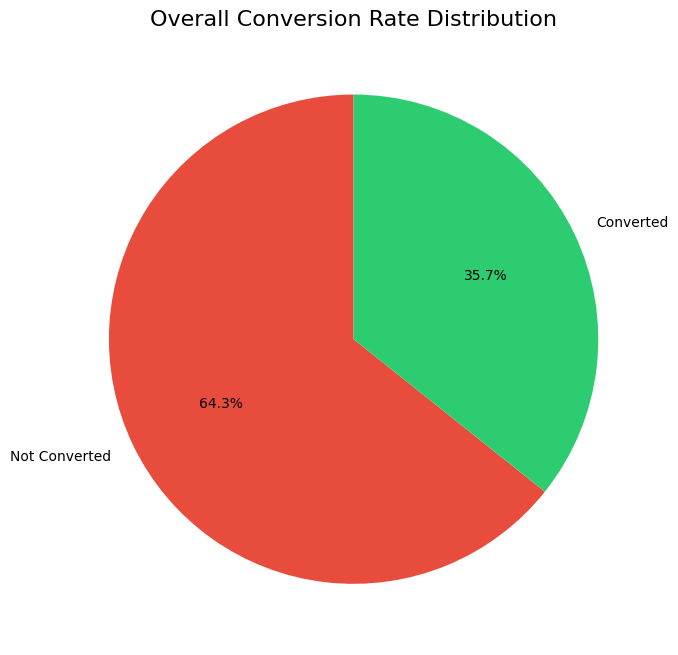

In [28]:
# Conversion Rate Distribution - Pie Chart
converted_count = df['Converted'].value_counts()
labels = ['Not Converted', 'Converted']

plt.figure(figsize=(7, 7))
plt.pie(converted_count.values, labels=labels, autopct='%1.1f%%',
        startangle=90, colors=['#e74c3c', '#2ecc71'])
plt.title('Overall Conversion Rate Distribution', fontsize=16)
plt.tight_layout()
plt.show()

In [29]:
# Project Summary
conv_membership = df.groupby('Membership Type')['Converted'].mean() * 100
conv_city = df.groupby('City')['Converted'].mean() * 100

print("=" * 50)
print("  E-COMMERCE CONVERSION RATE - SUMMARY")
print("=" * 50)
print(f"Total Customers      : {df.shape[0]}")
print(f"Total Converted      : {df['Converted'].sum()}")
print(f"Overall Conv. Rate   : {df['Converted'].mean()*100:.2f}%")
print(f"Best Membership Type : {conv_membership.idxmax()} ({conv_membership.max():.1f}%)")
print(f"Best City            : {conv_city.idxmax()} ({conv_city.max():.1f}%)")
print(f"Avg Total Spend      : ${df['Total Spend'].mean():,.2f}")
print(f"Avg Items Purchased  : {df['Items Purchased'].mean():.1f}")
print(f"Avg Customer Rating  : {df['Average Rating'].mean():.2f}")
print("=" * 50)

  E-COMMERCE CONVERSION RATE - SUMMARY
Total Customers      : 350
Total Converted      : 125
Overall Conv. Rate   : 35.71%
Best Membership Type : Gold (100.0%)
Best City            : New York (100.0%)
Avg Total Spend      : $845.38
Avg Items Purchased  : 12.6
Avg Customer Rating  : 4.02
